In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# =============================================================
# 1. LOAD DATA
# =============================================================
data = pd.read_csv('/Users/muhammadzuamaalamin/Documents/percobaancvd/datasetfix/heart_disease_new_dataset1.csv')
print("Shape awal:", data.shape)
print(data['CVD_LABEL'].value_counts())

Shape awal: (438693, 304)
CVD_LABEL
Healt                391852
Stroke Only           11518
CHD Only              11048
Heart Attack Only     10295
MI + CHD               8285
MI + Stroke            2137
All Three              2114
CHD + Stroke           1444
Name: count, dtype: int64


In [3]:
# =============================================================
# 2. HAPUS KOLOM MISSING VALUES >= 30%
# =============================================================
miss = data.isnull().mean() * 100
cols_to_drop_miss = miss[miss >= 30].index.tolist()

print(f"\nKolom dihapus karena missing >= 30% ({len(cols_to_drop_miss)}):")
print(cols_to_drop_miss)

data1 = data.drop(columns=cols_to_drop_miss)
print(f"\nShape setelah hapus missing: {data1.shape}")


Kolom dihapus karena missing >= 30% (155):
['CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'COLGSEX', 'NUMADULT', 'LANDSEX', 'NUMMEN', 'NUMWOMEN', 'RESPSLCT', 'CCLGHOUS', 'POORHLTH', 'BPMEDS', 'ASTHNOW', 'DIABAGE3', 'ARTHEXER', 'ARTHEDU', 'LMTJOIN3', 'ARTHDIS2', 'JOINPAI2', 'NUMHHOL3', 'NUMPHON3', 'PREGNANT', 'SMOKDAY2', 'AVEDRNK3', 'DRNK3GE5', 'MAXDRNKS', 'FLSHTMY3', 'IMFVPLA2', 'HIVTSTD3', 'PDIABTST', 'PREDIAB1', 'INSULIN1', 'BLDSUGAR', 'FEETCHK3', 'DOCTDIAB', 'CHKHEMO3', 'FEETCHK', 'EYEEXAM1', 'DIABEYE', 'DIABEDU', 'TOLDCFS', 'HAVECFS', 'WORKCFS', 'TOLDHEPC', 'TRETHEPC', 'PRIRHEPC', 'HAVEHEPC', 'HAVEHEPB', 'MEDSHEPB', 'HPVADVC4', 'HPVADSHT', 'TETANUS1', 'SHINGLE2', 'LCSFIRST', 'LCSLAST', 'LCSNUMCG', 'LCSCTSCN', 'HADMAM', 'HOWLONG', 'CERVSCRN', 'CRVCLCNC', 'CRVCLPAP', 'CRVCLHPV', 'HADHYST2', 'PSATEST1', 'PSATIME1', 'PCPSARS2', 'PCSTALK', 'HADSIGM4', 'COLNSIGM', 'COLNTES1', 'SIGMTES1', 'LASTSIG4', 'COLNCNCR', 'VIRCOLO1', 'VCLNTES1', 'SMALSTOL', 'STOLTEST', 'ST

In [4]:
# ============================================================
# DEFINISI FITUR (sudah deduplikasi)
# ============================================================
fitur_paper = [
    # --- Cardiovascular / Target ---
    'CVD_LABEL',    # Label/Target
    '_MICHD',       # Heart Problems (CHD/MI)
    'CVDSTRK3',     # Stroke
    'CVDCRHD4',     # Coronary Heart Disease
    'CVDINFR4',     # Heart Attack

    # --- Blood Pressure & Cholesterol ---
    '_RFHYPE6',     # High Blood Pressure (calculated)
    'BPHIGH6',      # Ever Told Blood Pressure High
    'TOLDHI3',      # High Cholesterol
    '_CHOLCH3',     # Cholesterol Check (calculated)
    'CHOLCHK3',     # Cholesterol Check (raw)

    # --- Metabolic & Chronic Conditions ---
    'DIABETE4',     # Diabetes
    'CHCKDNY2',     # Kidney Disease
    'CHCCOPD3',     # COPD
    'ASTHMA3',      # Asthma
    'ADDEPEV3',     # Depression
    '_DRDXAR3',     # Arthritis

    # --- BMI ---
    '_BMI5',        # BMI (continuous)
    '_BMI5CAT',     # BMI Category

    # --- Lifestyle ---
    'SMOKE100',     # Smoker
    '_TOTINDA',     # Physical Activity
    '_FRTLT1A',     # Fruits Consumption
    '_VEGLT1A',     # Veggies Consumption
    '_DRNKWK1',     # Alcohol Consumption

    # --- Health Status ---
    'GENHLTH',      # General Health
    'MENTHLTH',     # Mental Health
    'PHYSHLTH',     # Physical Health
    'DIFFWALK',     # Difficulty Walking
    'DECIDE',       # Difficulty Concentrating/Deciding

    # --- Healthcare Access ---
    '_HLTHPLN',     # Any Healthcare Coverage
    'MEDCOST1',     # No Doc because Cost
    'PERSDOC3',     # Personal Doctor
    'CHECKUP1',     # Last Routine Checkup

    # --- Preventive Care ---
    'PNEUVAC4',     # Pneumonia Vaccine
    'FLUSHOT7',     # Flu Shot
    '_AIDTST4',     # HIV Test

    # --- Demographics ---
    '_SEX',         # Sex
    '_AGEG5YR',     # Age Group
    'EDUCA',        # Education
    'INCOME3',      # Income
    'EMPLOY1',      # Employment Status
    '_PRACE1',      # Race
]

# Hapus duplikat sambil pertahankan urutan
fitur_paper = list(dict.fromkeys(fitur_paper))

# ============================================================
# CEK KOLOM DIABETES
# ============================================================
diabetes_cols = [c for c in data1.columns if 'DIAB' in c.upper()]
print("Kolom diabetes yang tersedia:", diabetes_cols)

# ============================================================
# CEK KETERSEDIAAN FITUR
# ============================================================
fitur_exist   = [c for c in fitur_paper if c in data1.columns]
fitur_missing = [c for c in fitur_paper if c not in data1.columns]

print(f"\n{'='*45}")
print(f"  Total fitur didefinisikan : {len(fitur_paper)}")
print(f"  Fitur ditemukan           : {len(fitur_exist)}")
print(f"  Fitur tidak ditemukan     : {len(fitur_missing)}")
print(f"{'='*45}")

if fitur_missing:
    print("\n⚠️  Fitur yang TIDAK ADA di dataset:")
    for i, col in enumerate(fitur_missing, 1):
        print(f"   {i:2}. {col}")

# ============================================================
# BUAT DATASET FINAL
# ============================================================
data_final = data1[fitur_exist].copy()

print(f"\n✅ Shape data final : {data_final.shape}")
print(f"\nFitur yang dipakai ({len(fitur_exist)} fitur):")
for i, col in enumerate(fitur_exist, 1):
    print(f"  {i:2}. {col}")

Kolom diabetes yang tersedia: ['DIABETE4']

  Total fitur didefinisikan : 41
  Fitur ditemukan           : 41
  Fitur tidak ditemukan     : 0

✅ Shape data final : (438693, 41)

Fitur yang dipakai (41 fitur):
   1. CVD_LABEL
   2. _MICHD
   3. CVDSTRK3
   4. CVDCRHD4
   5. CVDINFR4
   6. _RFHYPE6
   7. BPHIGH6
   8. TOLDHI3
   9. _CHOLCH3
  10. CHOLCHK3
  11. DIABETE4
  12. CHCKDNY2
  13. CHCCOPD3
  14. ASTHMA3
  15. ADDEPEV3
  16. _DRDXAR3
  17. _BMI5
  18. _BMI5CAT
  19. SMOKE100
  20. _TOTINDA
  21. _FRTLT1A
  22. _VEGLT1A
  23. _DRNKWK1
  24. GENHLTH
  25. MENTHLTH
  26. PHYSHLTH
  27. DIFFWALK
  28. DECIDE
  29. _HLTHPLN
  30. MEDCOST1
  31. PERSDOC3
  32. CHECKUP1
  33. PNEUVAC4
  34. FLUSHOT7
  35. _AIDTST4
  36. _SEX
  37. _AGEG5YR
  38. EDUCA
  39. INCOME3
  40. EMPLOY1
  41. _PRACE1


## Preprocessing 1

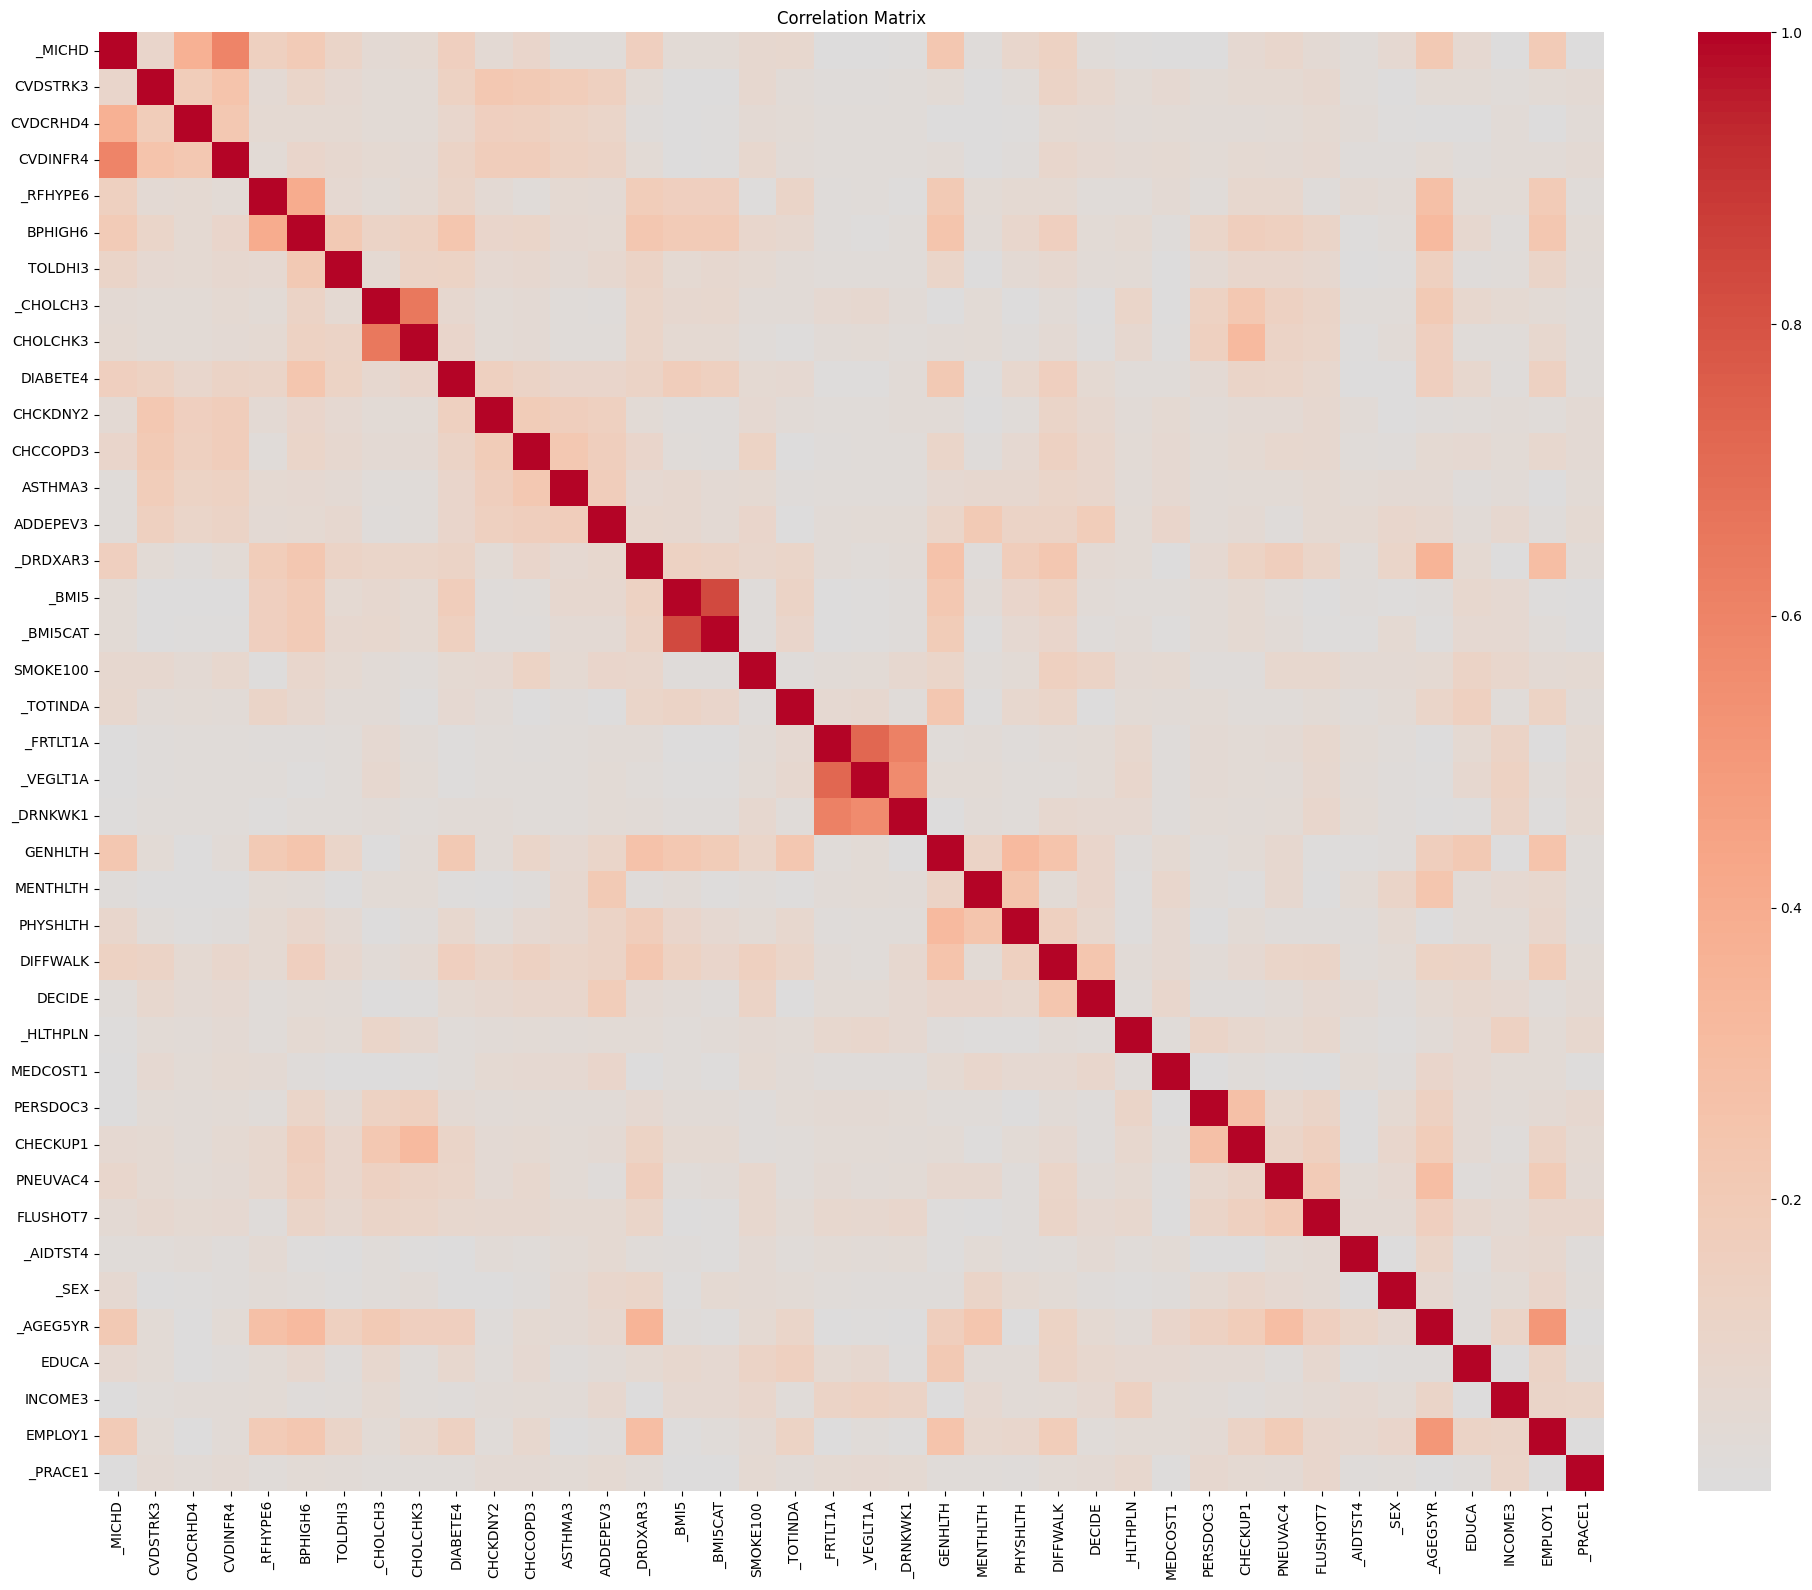

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung korelasi
corr_matrix = data_final.select_dtypes(include='float64').corr().abs()

# Visualisasi heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, 
            cmap='coolwarm',
            center=0,
            annot=False,  # ganti True kalau mau lihat angkanya (lambat kalau banyak fitur)
            fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [6]:
# Tampilkan pasangan fitur dengan korelasi > 0.85
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [(col, row, upper.loc[row, col]) 
             for col in upper.columns 
             for row in upper.index 
             if upper.loc[row, col] > 0.50]

high_corr_df = pd.DataFrame(high_corr, columns=['Fitur_1', 'Fitur_2', 'Korelasi'])
high_corr_df = high_corr_df.sort_values('Korelasi', ascending=False)

print(f"Pasangan fitur dengan korelasi > 0.85: {len(high_corr_df)}")
print(high_corr_df.to_string(index=False))

Pasangan fitur dengan korelasi > 0.85: 7
 Fitur_1  Fitur_2  Korelasi
_BMI5CAT    _BMI5  0.830420
_VEGLT1A _FRTLT1A  0.721476
CHOLCHK3 _CHOLCH3  0.648654
_DRNKWK1 _FRTLT1A  0.609881
CVDINFR4   _MICHD  0.600431
_DRNKWK1 _VEGLT1A  0.569375
 EMPLOY1 _AGEG5YR  0.511347


In [7]:
data_final = data_final.drop(columns=['_BMI5CAT'])

In [8]:
# Cara 1 - Value counts semua kolom sekaligus
for col in data_final.columns:
    print(f"\n{'='*50}")
    print(f"Kolom: {col}")
    print(data_final[col].value_counts(dropna=False))


Kolom: CVD_LABEL
CVD_LABEL
Healt                391852
Stroke Only           11518
CHD Only              11048
Heart Attack Only     10295
MI + CHD               8285
MI + Stroke            2137
All Three              2114
CHD + Stroke           1444
Name: count, dtype: int64

Kolom: _MICHD
_MICHD
2.0    398735
1.0     35323
NaN      4635
Name: count, dtype: int64

Kolom: CVDSTRK3
CVDSTRK3
2.0    420051
1.0     17213
7.0      1130
9.0       297
NaN         2
Name: count, dtype: int64

Kolom: CVDCRHD4
CVDCRHD4
2.0    411527
1.0     22891
7.0      3934
9.0       339
NaN         2
Name: count, dtype: int64

Kolom: CVDINFR4
CVDINFR4
2.0    413207
1.0     22831
7.0      2319
9.0       334
NaN         2
Name: count, dtype: int64

Kolom: _RFHYPE6
_RFHYPE6
1.0    264648
2.0    172133
9.0      1912
Name: count, dtype: int64

Kolom: BPHIGH6
BPHIGH6
3.0    256603
1.0    172133
4.0      4571
2.0      3474
7.0      1191
9.0       719
NaN         2
Name: count, dtype: int64

Kolom: TOLDHI3
TOLDHI3


In [9]:
import pandas as pd
import numpy as np

# Nilai yang perlu diganti NaN per variabel
nan_map = {
    'CVDSTRK3':  [7.0, 9.0],
    'CVDCRHD4':  [7.0, 9.0],
    'CVDINFR4':  [7.0, 9.0],
    'BPHIGH6':   [7.0, 9.0],
    'TOLDHI3':   [7.0, 9.0],
    '_CHOLCH3':  [9.0],
    'CHOLCHK3':  [7.0, 9.0],
    'DIABETE4':  [7.0, 9.0],
    'CHCKDNY2':  [7.0, 9.0],
    'CHCCOPD3':  [7.0, 9.0],
    'ASTHMA3':   [7.0, 9.0],
    'ADDEPEV3':  [7.0, 9.0],
    '_DRDXAR3':  [],           # sudah NaN semua
    'SMOKE100':  [7.0, 9.0],
    '_TOTINDA':  [9.0],
    '_FRTLT1A':  [9.0],
    '_VEGLT1A':  [9.0],
    'GENHLTH':   [7.0, 9.0],
    'MENTHLTH':  [77.0, 99.0],
    'PHYSHLTH':  [77.0, 99.0],
    'DIFFWALK':  [7.0, 9.0],
    'DECIDE':    [7.0, 9.0],
    '_HLTHPLN':  [9.0],
    'MEDCOST1':  [7.0, 9.0],
    'PERSDOC3':  [7.0, 9.0],
    'CHECKUP1':  [7.0, 8.0, 9.0],
    'PNEUVAC4':  [7.0, 9.0],
    'FLUSHOT7':  [7.0, 9.0],
    '_AIDTST4':  [9.0],
    'EDUCA':     [9.0],
    'INCOME3':   [77.0, 99.0],
    'EMPLOY1':   [9.0],
    '_PRACE1':   [77.0, 99.0],
}

for col, invalid_vals in nan_map.items():
    if col in data_final.columns and invalid_vals:
        data_final[col] = data_final[col].replace(invalid_vals, np.nan)

print("Selesai! Cek missing values:")
print(data_final[nan_map.keys()].isna().sum())

Selesai! Cek missing values:
CVDSTRK3     1429
CVDCRHD4     4275
CVDINFR4     2655
BPHIGH6      1912
TOLDHI3     63980
_CHOLCH3    29782
CHOLCHK3    29782
DIABETE4      985
CHCKDNY2     1813
CHCCOPD3     2107
ASTHMA3      1746
ADDEPEV3     2517
_DRDXAR3     2896
SMOKE100    24461
_TOTINDA      928
_FRTLT1A    51087
_VEGLT1A    60127
GENHLTH      1161
MENTHLTH     7917
PHYSHLTH     9494
DIFFWALK    19830
DECIDE      19980
_HLTHPLN    17397
MEDCOST1     1364
PERSDOC3     3705
CHECKUP1     8216
PNEUVAC4    62801
FLUSHOT7    31392
_AIDTST4    51856
EDUCA        2478
INCOME3     94413
EMPLOY1      8251
_PRACE1     13363
dtype: int64


In [10]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438693 entries, 0 to 438692
Data columns (total 40 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   CVD_LABEL  438693 non-null  object 
 1   _MICHD     434058 non-null  float64
 2   CVDSTRK3   437264 non-null  float64
 3   CVDCRHD4   434418 non-null  float64
 4   CVDINFR4   436038 non-null  float64
 5   _RFHYPE6   438693 non-null  float64
 6   BPHIGH6    436781 non-null  float64
 7   TOLDHI3    374713 non-null  float64
 8   _CHOLCH3   408911 non-null  float64
 9   CHOLCHK3   408911 non-null  float64
 10  DIABETE4   437708 non-null  float64
 11  CHCKDNY2   436880 non-null  float64
 12  CHCCOPD3   436586 non-null  float64
 13  ASTHMA3    436947 non-null  float64
 14  ADDEPEV3   436176 non-null  float64
 15  _DRDXAR3   435797 non-null  float64
 16  _BMI5      391841 non-null  float64
 17  SMOKE100   414232 non-null  float64
 18  _TOTINDA   437765 non-null  float64
 19  _FRTLT1A   387606 non-n

In [11]:
data_final.describe()

,_MICHD,CVDSTRK3,CVDCRHD4,CVDINFR4,_RFHYPE6,BPHIGH6,TOLDHI3,_CHOLCH3,CHOLCHK3,DIABETE4,...,CHECKUP1,PNEUVAC4,FLUSHOT7,_AIDTST4,_SEX,_AGEG5YR,EDUCA,INCOME3,EMPLOY1,_PRACE1
count,434058.000000,437264.000000,434418.000000,436038.000000,438693.000000,436781.000000,374713.000000,408911.000000,408911.000000,437708.000000,...,430477.000000,375892.000000,407301.000000,386837.000000,438693.000000,438693.000000,436215.000000,344280.000000,430442.000000,425330.000000
mean,1.918621,1.960635,1.947307,1.947640,1.427244,2.214323,1.600430,1.186539,2.405142,2.750752,...,1.356802,1.596778,1.479098,1.666506,1.535529,7.726016,5.012790,6.698330,3.747225,1.431935
std,0.273416,0.194463,0.223421,0.222752,0.699127,0.988691,0.489811,0.552422,1.300781,0.704141,...,0.772044,0.490545,0.499564,0.471462,0.498737,3.645926,1.007272,2.422855,2.837228,1.143380
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,4.000000,5.000000,1.000000,1.000000
50%,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,3.000000,...,1.000000,2.000000,1.000000,2.000000,2.000000,8.000000,5.000000,7.000000,2.000000,1.000000
75%,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,1.000000,2.000000,3.000000,...,1.000000,2.000000,2.000000,2.000000,2.000000,11.000000,6.000000,9.000000,7.000000,1.000000
max,2.000000,2.000000,2.000000,2.000000,9.000000,4.000000,2.000000,3.000000,8.000000,4.000000,...,4.000000,2.000000,2.000000,2.000000,2.000000,14.000000,6.000000,11.000000,8.000000,8.000000


In [12]:
data_final.isna().sum()

CVD_LABEL        0
_MICHD        4635
CVDSTRK3      1429
CVDCRHD4      4275
CVDINFR4      2655
_RFHYPE6         0
BPHIGH6       1912
TOLDHI3      63980
_CHOLCH3     29782
CHOLCHK3     29782
DIABETE4       985
CHCKDNY2      1813
CHCCOPD3      2107
ASTHMA3       1746
ADDEPEV3      2517
_DRDXAR3      2896
_BMI5        46852
SMOKE100     24461
_TOTINDA       928
_FRTLT1A     51087
_VEGLT1A     60127
_DRNKWK1         0
GENHLTH       1161
MENTHLTH      7917
PHYSHLTH      9494
DIFFWALK     19830
DECIDE       19980
_HLTHPLN     17397
MEDCOST1      1364
PERSDOC3      3705
CHECKUP1      8216
PNEUVAC4     62801
FLUSHOT7     31392
_AIDTST4     51856
_SEX             0
_AGEG5YR         0
EDUCA         2478
INCOME3      94413
EMPLOY1       8251
_PRACE1      13363
dtype: int64

In [13]:
severity_map = {
    'Healt'            : 0,  # Sehat
    'Stroke Only'       : 1,  # Level 1 → 1 kondisi
    'CHD Only'          : 1,  # Level 1 → 1 kondisi
    'Heart Attack Only' : 1,  # Level 1 → 1 kondisi
    'MI + CHD'          : 1,  # Level 2 → 2 kondisi
    'MI + Stroke'       : 1,  # Level 2 → 2 kondisi
    'CHD + Stroke'      : 1,  # Level 2 → 2 kondisi
    'All Three'         : 1,  # Level 3 → 3 kondisi
}

data_final['CVD_SEVERITY'] = data_final['CVD_LABEL'].map(severity_map)

# Verifikasi
print(data_final['CVD_SEVERITY'].value_counts())
print(f"\nTotal : {len(data1):,}")

CVD_SEVERITY
0    391852
1     46841
Name: count, dtype: int64

Total : 438,693


In [14]:
data_final.isnull().sum()

CVD_LABEL           0
_MICHD           4635
CVDSTRK3         1429
CVDCRHD4         4275
CVDINFR4         2655
_RFHYPE6            0
BPHIGH6          1912
TOLDHI3         63980
_CHOLCH3        29782
CHOLCHK3        29782
DIABETE4          985
CHCKDNY2         1813
CHCCOPD3         2107
ASTHMA3          1746
ADDEPEV3         2517
_DRDXAR3         2896
_BMI5           46852
SMOKE100        24461
_TOTINDA          928
_FRTLT1A        51087
_VEGLT1A        60127
_DRNKWK1            0
GENHLTH          1161
MENTHLTH         7917
PHYSHLTH         9494
DIFFWALK        19830
DECIDE          19980
_HLTHPLN        17397
MEDCOST1         1364
PERSDOC3         3705
CHECKUP1         8216
PNEUVAC4        62801
FLUSHOT7        31392
_AIDTST4        51856
_SEX                0
_AGEG5YR            0
EDUCA            2478
INCOME3         94413
EMPLOY1          8251
_PRACE1         13363
CVD_SEVERITY        0
dtype: int64

In [15]:
data_final

,CVD_LABEL,_MICHD,CVDSTRK3,CVDCRHD4,CVDINFR4,_RFHYPE6,BPHIGH6,TOLDHI3,_CHOLCH3,CHOLCHK3,...,PNEUVAC4,FLUSHOT7,_AIDTST4,_SEX,_AGEG5YR,EDUCA,INCOME3,EMPLOY1,_PRACE1,CVD_SEVERITY
0,Healt,2.0,2.0,2.0,2.0,1.0,3.0,1.0,1.0,2.0,...,1.0,1.0,2.0,2.0,11.0,4.0,5.0,7.0,1.0,0
1,CHD Only,1.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,...,2.0,2.0,2.0,2.0,10.0,6.0,NaN,8.0,2.0,1
2,CHD Only,1.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0,2.0,...,2.0,2.0,2.0,2.0,11.0,4.0,3.0,7.0,2.0,1
3,Healt,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,2.0,...,2.0,1.0,2.0,2.0,9.0,4.0,7.0,7.0,1.0,0
4,MI + Stroke,1.0,1.0,NaN,1.0,1.0,4.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,12.0,3.0,4.0,8.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438688,Healt,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,6.0,...,1.0,2.0,1.0,2.0,3.0,4.0,5.0,1.0,NaN,0
438689,Healt,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,...,2.0,2.0,2.0,1.0,13.0,4.0,1.0,8.0,6.0,0
438690,Healt,2.0,2.0,2.0,2.0,1.0,3.0,1.0,1.0,2.0,...,2.0,2.0,1.0,1.0,7.0,6.0,10.0,7.0,2.0,0
438691,Healt,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,...,2.0,2.0,1.0,1.0,10.0,4.0,6.0,7.0,NaN,0


In [16]:
data_final = data_final.drop(columns=['CVD_SEVERITY','CVD_LABEL','CVDINFR4','CVDCRHD4'])
data_final

,_MICHD,CVDSTRK3,_RFHYPE6,BPHIGH6,TOLDHI3,_CHOLCH3,CHOLCHK3,DIABETE4,CHCKDNY2,CHCCOPD3,...,CHECKUP1,PNEUVAC4,FLUSHOT7,_AIDTST4,_SEX,_AGEG5YR,EDUCA,INCOME3,EMPLOY1,_PRACE1
0,2.0,2.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,1.0,...,2.0,1.0,1.0,2.0,2.0,11.0,4.0,5.0,7.0,1.0
1,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,...,1.0,2.0,2.0,2.0,2.0,10.0,6.0,NaN,8.0,2.0
2,1.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,2.0,2.0,...,1.0,2.0,2.0,2.0,2.0,11.0,4.0,3.0,7.0,2.0
3,2.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,...,1.0,2.0,1.0,2.0,2.0,9.0,4.0,7.0,7.0,1.0
4,1.0,1.0,1.0,4.0,1.0,1.0,2.0,1.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,12.0,3.0,4.0,8.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438688,2.0,2.0,2.0,1.0,2.0,1.0,6.0,2.0,2.0,1.0,...,4.0,1.0,2.0,1.0,2.0,3.0,4.0,5.0,1.0,NaN
438689,2.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,2.0,2.0,...,1.0,2.0,2.0,2.0,1.0,13.0,4.0,1.0,8.0,6.0
438690,2.0,2.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,2.0,...,1.0,2.0,2.0,1.0,1.0,7.0,6.0,10.0,7.0,2.0
438691,2.0,2.0,2.0,1.0,2.0,1.0,2.0,3.0,2.0,2.0,...,1.0,2.0,2.0,1.0,1.0,10.0,4.0,6.0,7.0,NaN


In [17]:
data_new = data_final.dropna()
print(f"Sebelum : {len(data1)} baris")
print(f"Sesudah : {len(data_new)} baris")
print(f"Terhapus: {len(data1) - len(data_new)} baris")

Sebelum : 438693 baris
Sesudah : 206064 baris
Terhapus: 232629 baris


In [18]:
data_new['_MICHD'].value_counts()

_MICHD
2.0    188015
1.0     18049
Name: count, dtype: int64

In [19]:
severity_map = {
    2.0       : 0,  # Sehat
    1.0       : 1,  # Level 1 → 1 kondisi
}
data_new['_MICHD'] = data_new['_MICHD'].map(severity_map)

# Verifikasi
print(data_new['_MICHD'].value_counts())
print(f"\nTotal : {len(data1):,}")

_MICHD
0    188015
1     18049
Name: count, dtype: int64

Total : 438,693


/var/folders/c1/0skxdwdx0zdcpl8hlxr2xcz40000gn/T/ipykernel_2846/2707975189.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_new['_MICHD'] = data_new['_MICHD'].map(severity_map)


In [20]:
data_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 206064 entries, 0 to 438692
Data columns (total 37 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   _MICHD    206064 non-null  int64  
 1   CVDSTRK3  206064 non-null  float64
 2   _RFHYPE6  206064 non-null  float64
 3   BPHIGH6   206064 non-null  float64
 4   TOLDHI3   206064 non-null  float64
 5   _CHOLCH3  206064 non-null  float64
 6   CHOLCHK3  206064 non-null  float64
 7   DIABETE4  206064 non-null  float64
 8   CHCKDNY2  206064 non-null  float64
 9   CHCCOPD3  206064 non-null  float64
 10  ASTHMA3   206064 non-null  float64
 11  ADDEPEV3  206064 non-null  float64
 12  _DRDXAR3  206064 non-null  float64
 13  _BMI5     206064 non-null  float64
 14  SMOKE100  206064 non-null  float64
 15  _TOTINDA  206064 non-null  float64
 16  _FRTLT1A  206064 non-null  float64
 17  _VEGLT1A  206064 non-null  float64
 18  _DRNKWK1  206064 non-null  float64
 19  GENHLTH   206064 non-null  float64
 20  MENTHLTH 

In [21]:
X = data_new.drop(columns=['_MICHD'])
y = data_new['_MICHD']

### Training Model

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 164851 entries, 4662 to 39906
Data columns (total 36 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   CVDSTRK3  164851 non-null  float64
 1   _RFHYPE6  164851 non-null  float64
 2   BPHIGH6   164851 non-null  float64
 3   TOLDHI3   164851 non-null  float64
 4   _CHOLCH3  164851 non-null  float64
 5   CHOLCHK3  164851 non-null  float64
 6   DIABETE4  164851 non-null  float64
 7   CHCKDNY2  164851 non-null  float64
 8   CHCCOPD3  164851 non-null  float64
 9   ASTHMA3   164851 non-null  float64
 10  ADDEPEV3  164851 non-null  float64
 11  _DRDXAR3  164851 non-null  float64
 12  _BMI5     164851 non-null  float64
 13  SMOKE100  164851 non-null  float64
 14  _TOTINDA  164851 non-null  float64
 15  _FRTLT1A  164851 non-null  float64
 16  _VEGLT1A  164851 non-null  float64
 17  _DRNKWK1  164851 non-null  float64
 18  GENHLTH   164851 non-null  float64
 19  MENTHLTH  164851 non-null  float64
 20  PHYSHLT

In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,recall_score

# Hitung scale_pos_weight untuk class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Training model
model = XGBClassifier(
    n_estimators     = 100,
    max_depth        = 6,
    learning_rate    = 0.1,
    scale_pos_weight = scale_pos_weight,
    eval_metric      = 'logloss',
    random_state     = 42
)

model.fit(X_train, y_train)

# %%
# Evaluasi
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Sehat', 'CVD']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

       Sehat       0.97      0.75      0.85     37603
         CVD       0.23      0.78      0.35      3610

    accuracy                           0.75     41213
   macro avg       0.60      0.76      0.60     41213
weighted avg       0.91      0.75      0.80     41213

AUC-ROC: 0.8441

Confusion Matrix:
[[28141  9462]
 [  790  2820]]


Top 20 Feature Importance:
     feature  importance
0   _RFHYPE6    0.332075
1    GENHLTH    0.092451
2    EMPLOY1    0.090890
3   _AGEG5YR    0.060270
4    TOLDHI3    0.042506
5       _SEX    0.035289
6   PNEUVAC4    0.035215
7   CVDSTRK3    0.027688
8   CHCCOPD3    0.026804
9   DIFFWALK    0.023777
10   BPHIGH6    0.023478
11  SMOKE100    0.022720
12  DIABETE4    0.021389
13  PERSDOC3    0.016249
14  CHOLCHK3    0.016059
15  _DRDXAR3    0.014932
16  CHCKDNY2    0.012954
17  MEDCOST1    0.007776
18  ADDEPEV3    0.007463
19   INCOME3    0.006581
20     EDUCA    0.006576
21   _PRACE1    0.006272
22  _DRNKWK1    0.006232
23  _AIDTST4    0.006061
24  _TOTINDA    0.005406
25  FLUSHOT7    0.005250
26    DECIDE    0.005104
27   ASTHMA3    0.005089
28     _BMI5    0.004960
29  _CHOLCH3    0.004939
30  CHECKUP1    0.004879
31  _VEGLT1A    0.004840
32  PHYSHLTH    0.004774
33  _FRTLT1A    0.004768
34  MENTHLTH    0.004422
35  _HLTHPLN    0.003861


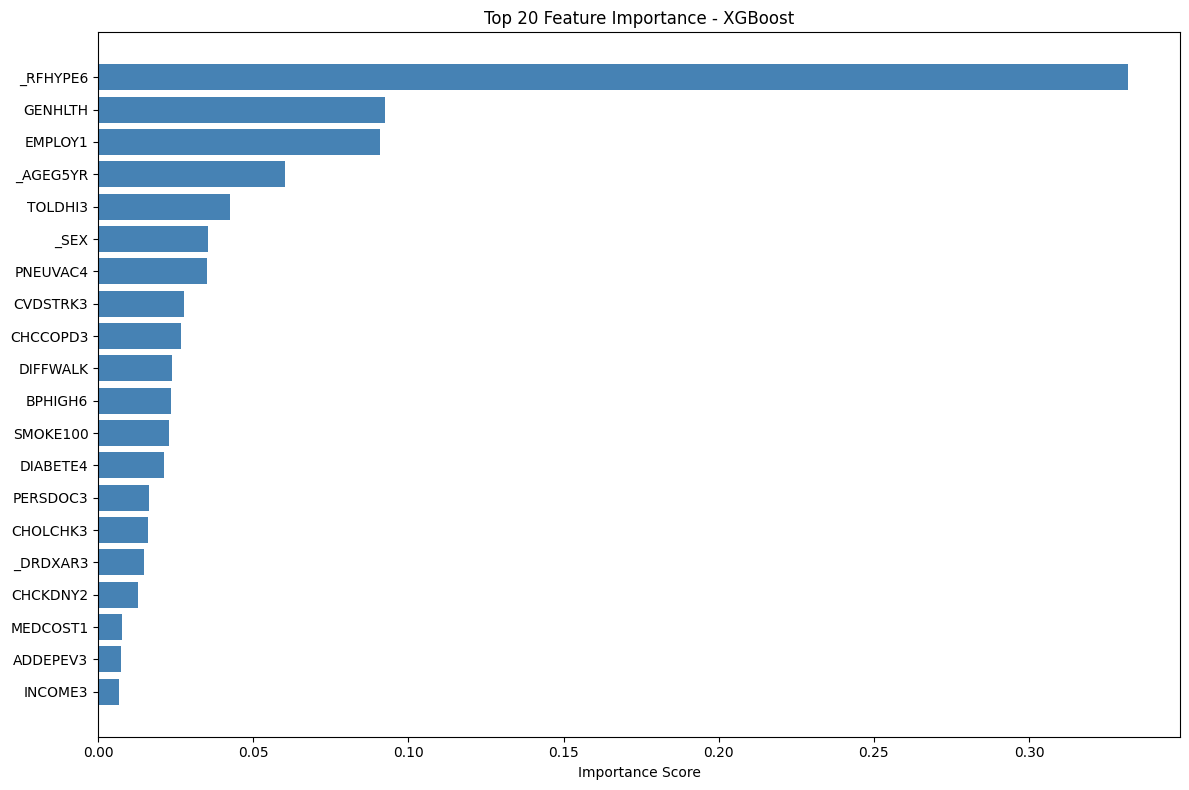

In [26]:
import matplotlib.pyplot as plt
# ── 1. Feature Importance dari model XGBoost yang sudah ditraining ──
importances = model.feature_importances_
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 20 Feature Importance:")
print(feat_imp_df.head(50))

# %%
# ── 2. Plot Feature Importance ──
plt.figure(figsize=(12, 8))
top_n = 20
plt.barh(
    feat_imp_df['feature'][:top_n][::-1],
    feat_imp_df['importance'][:top_n][::-1],
    color='steelblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance - XGBoost')
plt.tight_layout()
plt.show()

In [30]:
import numpy as np
from tqdm import tqdm
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.under_sampling import TomekLinks, NearMiss
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import pandas as pd

# ── 1. Definisi kuartil & resamplers ────────────────────────────────────────
kuartils = [1, 2, 3]  # Q1=25%, Q2=50%, Q3=75%

resamplers = {
    # Baseline
    'scale_pos_weight'  : None,

    # Over-sampling
    'SMOTE'             : SMOTE(random_state=42),
    'BorderlineSMOTE'   : BorderlineSMOTE(random_state=42),
    'ADASYN'            : ADASYN(random_state=42),

    # Combine (over + under)
    'SMOTETomek'        : SMOTETomek(random_state=42),
    'SMOTEENN'          : SMOTEENN(random_state=42),

    # Under-sampling
    'TomekLinks'        : TomekLinks(n_jobs=-1),
    'NearMiss-1'        : NearMiss(version=1, n_jobs=-1),
    'NearMiss-2'        : NearMiss(version=2, n_jobs=-1),
    'NearMiss-3'        : NearMiss(version=3, n_jobs=-1),
}

# ── 2. Loop kuartil × resampler ─────────────────────────────────────────────
results_all = {}
confusion_matrices = {}
N_total = len(feat_imp_df)

outer_bar = tqdm(kuartils, desc="Kuartil", position=0)

for Q in outer_bar:
    N_FEATURES = int(np.ceil(N_total * Q / 4))  # 25%, 50%, 75%, 100%
    selected_features = feat_imp_df['feature'].head(N_FEATURES).tolist()

    X_train_q = X_train[selected_features]
    X_test_q  = X_test[selected_features]

    outer_bar.set_postfix({'fitur': N_FEATURES})

    inner_bar = tqdm(resamplers.items(), desc=f"  Resampler (Q={Q})", position=1, leave=False)

    for resampler_name, sampler in inner_bar:
        inner_bar.set_postfix({'method': resampler_name})

        if sampler is None:
            X_res, y_res = X_train_q, y_train
            spw = (y_train == 0).sum() / (y_train == 1).sum()
        else:
            X_res, y_res = sampler.fit_resample(X_train_q, y_train)
            spw = 1.0

        xgb_model_q = XGBClassifier(
            n_estimators     = 300,
            max_depth        = 6,
            learning_rate    = 0.05,
            subsample        = 0.8,
            colsample_bytree = 0.8,
            scale_pos_weight = spw,
            eval_metric      = 'logloss',
            random_state     = 42,
            n_jobs           = -1
        )
        xgb_model_q.fit(X_res, y_res)

        y_pred = xgb_model_q.predict(X_test_q)
        y_prob = xgb_model_q.predict_proba(X_test_q)[:, 1]
        report = classification_report(y_test, y_pred, output_dict=True)
        cm     = confusion_matrix(y_test, y_pred)

        key = f'Q{Q}_{resampler_name}'
        results_all[key] = {
            'Kuartil'      : Q,
            'Label Kuartil': f'Q{Q} ({Q*25}%)',
            'N Fitur'      : N_FEATURES,
            'Resampler'    : resampler_name,
            'Recall CVD'   : report['1']['recall'],
            'Precision CVD': report['1']['precision'],
            'F1 CVD'       : report['1']['f1-score'],
            'F1 Macro'     : report['macro avg']['f1-score'],
            'F1 Weighted'  : report['weighted avg']['f1-score'],
            'Accuracy'     : report['accuracy'],
            'AUC'          : roc_auc_score(y_test, y_prob),
            'TN'           : cm[0, 0],
            'FP'           : cm[0, 1],
            'FN'           : cm[1, 0],
            'TP'           : cm[1, 1],
        }
        confusion_matrices[key] = cm

Kuartil:   0%|          | 0/3 [00:00<?, ?it/s, fitur=9]/opt/homebrew/lib/python3.11/site-packages/imblearn/under_sampling/_prototype_selection/_nearmiss.py:206: UserWarning: The number of the samples to be selected is larger than the number of samples available. The balancing ratio cannot be ensure and all samples will be returned.
  warnings.warn(
Kuartil: 100%|██████████| 3/3 [13:00<00:00, 260.04s/it, fitur=27]


In [31]:
# ── 3. Tabel hasil ───────────────────────────────────────────────────────────
results_df = pd.DataFrame(results_all).T.round(4)
results_df[['Kuartil', 'N Fitur', 'TN', 'FP', 'FN', 'TP']] = \
    results_df[['Kuartil', 'N Fitur', 'TN', 'FP', 'FN', 'TP']].astype(int)

print("\n── Perbandingan Semua Kombinasi (sort by F1 Macro) ──")
cols_show = ['Label Kuartil', 'N Fitur', 'Resampler',
             'Recall CVD', 'Precision CVD', 'F1 CVD',
             'F1 Macro', 'F1 Weighted', 'Accuracy', 'AUC']
print(results_df[cols_show].sort_values('F1 Macro', ascending=False).to_string())

# ── 4. Confusion Matrix semua kombinasi ─────────────────────────────────────
print("\n── Confusion Matrix per Kombinasi ──")
print(f"{'Key':<30} {'TN':>6} {'FP':>6} {'FN':>6} {'TP':>6}")
print("-" * 54)
for key, row in results_df.sort_values('F1 Macro', ascending=False).iterrows():
    print(f"{key:<30} {int(row['TN']):>6} {int(row['FP']):>6} {int(row['FN']):>6} {int(row['TP']):>6}")

# ── 5. Hasil terbaik ─────────────────────────────────────────────────────────
best     = results_df.sort_values('F1 Macro', ascending=False).iloc[0]
best_key = results_df.sort_values('F1 Macro', ascending=False).index[0]

print(f"\n✅ Kombinasi terbaik (berdasarkan F1 Macro):")
print(f"   Kuartil      : {best['Label Kuartil']}")
print(f"   N Fitur      : {best['N Fitur']}")
print(f"   Resampler    : {best['Resampler']}")
print(f"   Recall CVD   : {best['Recall CVD']}")
print(f"   Precision CVD: {best['Precision CVD']}")
print(f"   F1 CVD       : {best['F1 CVD']}")
print(f"   F1 Macro     : {best['F1 Macro']}")
print(f"   F1 Weighted  : {best['F1 Weighted']}")
print(f"   AUC          : {best['AUC']}")
print(f"\n   Confusion Matrix ({best_key}):")
print(f"   {'':15} Pred 0   Pred 1")
print(f"   {'Actual 0':15} {int(best['TN']):>6}   {int(best['FP']):>6}")
print(f"   {'Actual 1':15} {int(best['FN']):>6}   {int(best['TP']):>6}")


── Perbandingan Semua Kombinasi (sort by F1 Macro) ──
                    Label Kuartil  N Fitur         Resampler Recall CVD Precision CVD    F1 CVD  F1 Macro F1 Weighted  Accuracy       AUC
Q2_SMOTEENN              Q2 (50%)       18          SMOTEENN    0.45651      0.353724  0.398597  0.665768    0.886135  0.879334  0.843542
Q3_SMOTEENN              Q3 (75%)       27          SMOTEENN   0.555956      0.316163  0.403093  0.660535    0.872877  0.855774  0.845361
Q2_SMOTETomek            Q2 (50%)       18        SMOTETomek   0.386704      0.336548  0.359887  0.646689    0.883248  0.879504  0.826881
Q2_SMOTE                 Q2 (50%)       18             SMOTE   0.386427      0.336145  0.359536  0.646486    0.883167  0.879407  0.826677
Q2_ADASYN                Q2 (50%)       18            ADASYN   0.377285      0.332438  0.353445  0.643378    0.882518  0.879092  0.822818
Q2_BorderlineSMOTE       Q2 (50%)       18   BorderlineSMOTE    0.39723      0.322755  0.356141  0.643212    0.879992


Skenario : Q2_SMOTEENN | 18 fitur (50% teratas)


Q2_SMOTEENN: 100%|██████████| 8/8 [02:01<00:00, 15.16s/it]



Skenario : Q3_SMOTEENN | 27 fitur (75% teratas)


Q3_SMOTEENN:  75%|███████▌  | 6/8 [04:41<03:03, 91.67s/it]/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Q3_SMOTEENN: 100%|██████████| 8/8 [05:03<00:00, 37.90s/it]



── Perbandingan Semua Skenario × Model (sort by F1 Macro) ──
                                   Skenario   Kuartil               Model  N Fitur  F1 Macro F1 Weighted Recall CVD Precision CVD    F1 CVD  Accuracy       AUC
Q2_SMOTEENN_XGBoost             Q2_SMOTEENN  Q2 (50%)             XGBoost       18  0.665768    0.886135    0.45651      0.353724  0.398597  0.879334  0.843542
Q2_SMOTEENN_CatBoost            Q2_SMOTEENN  Q2 (50%)            CatBoost       18  0.663858    0.890159   0.408587      0.372099   0.38949  0.887802  0.842564
Q2_SMOTEENN_GradientBoosting    Q2_SMOTEENN  Q2 (50%)    GradientBoosting       18  0.663752    0.886148   0.445706      0.353238  0.394121  0.879965  0.843369
Q2_SMOTEENN_LightGBM            Q2_SMOTEENN  Q2 (50%)            LightGBM       18  0.663596    0.886647   0.440166      0.355243  0.393171  0.880984  0.843786
Q3_SMOTEENN_CatBoost            Q3_SMOTEENN  Q3 (75%)            CatBoost       27  0.661999    0.874785   0.545983      0.320644  0.40401

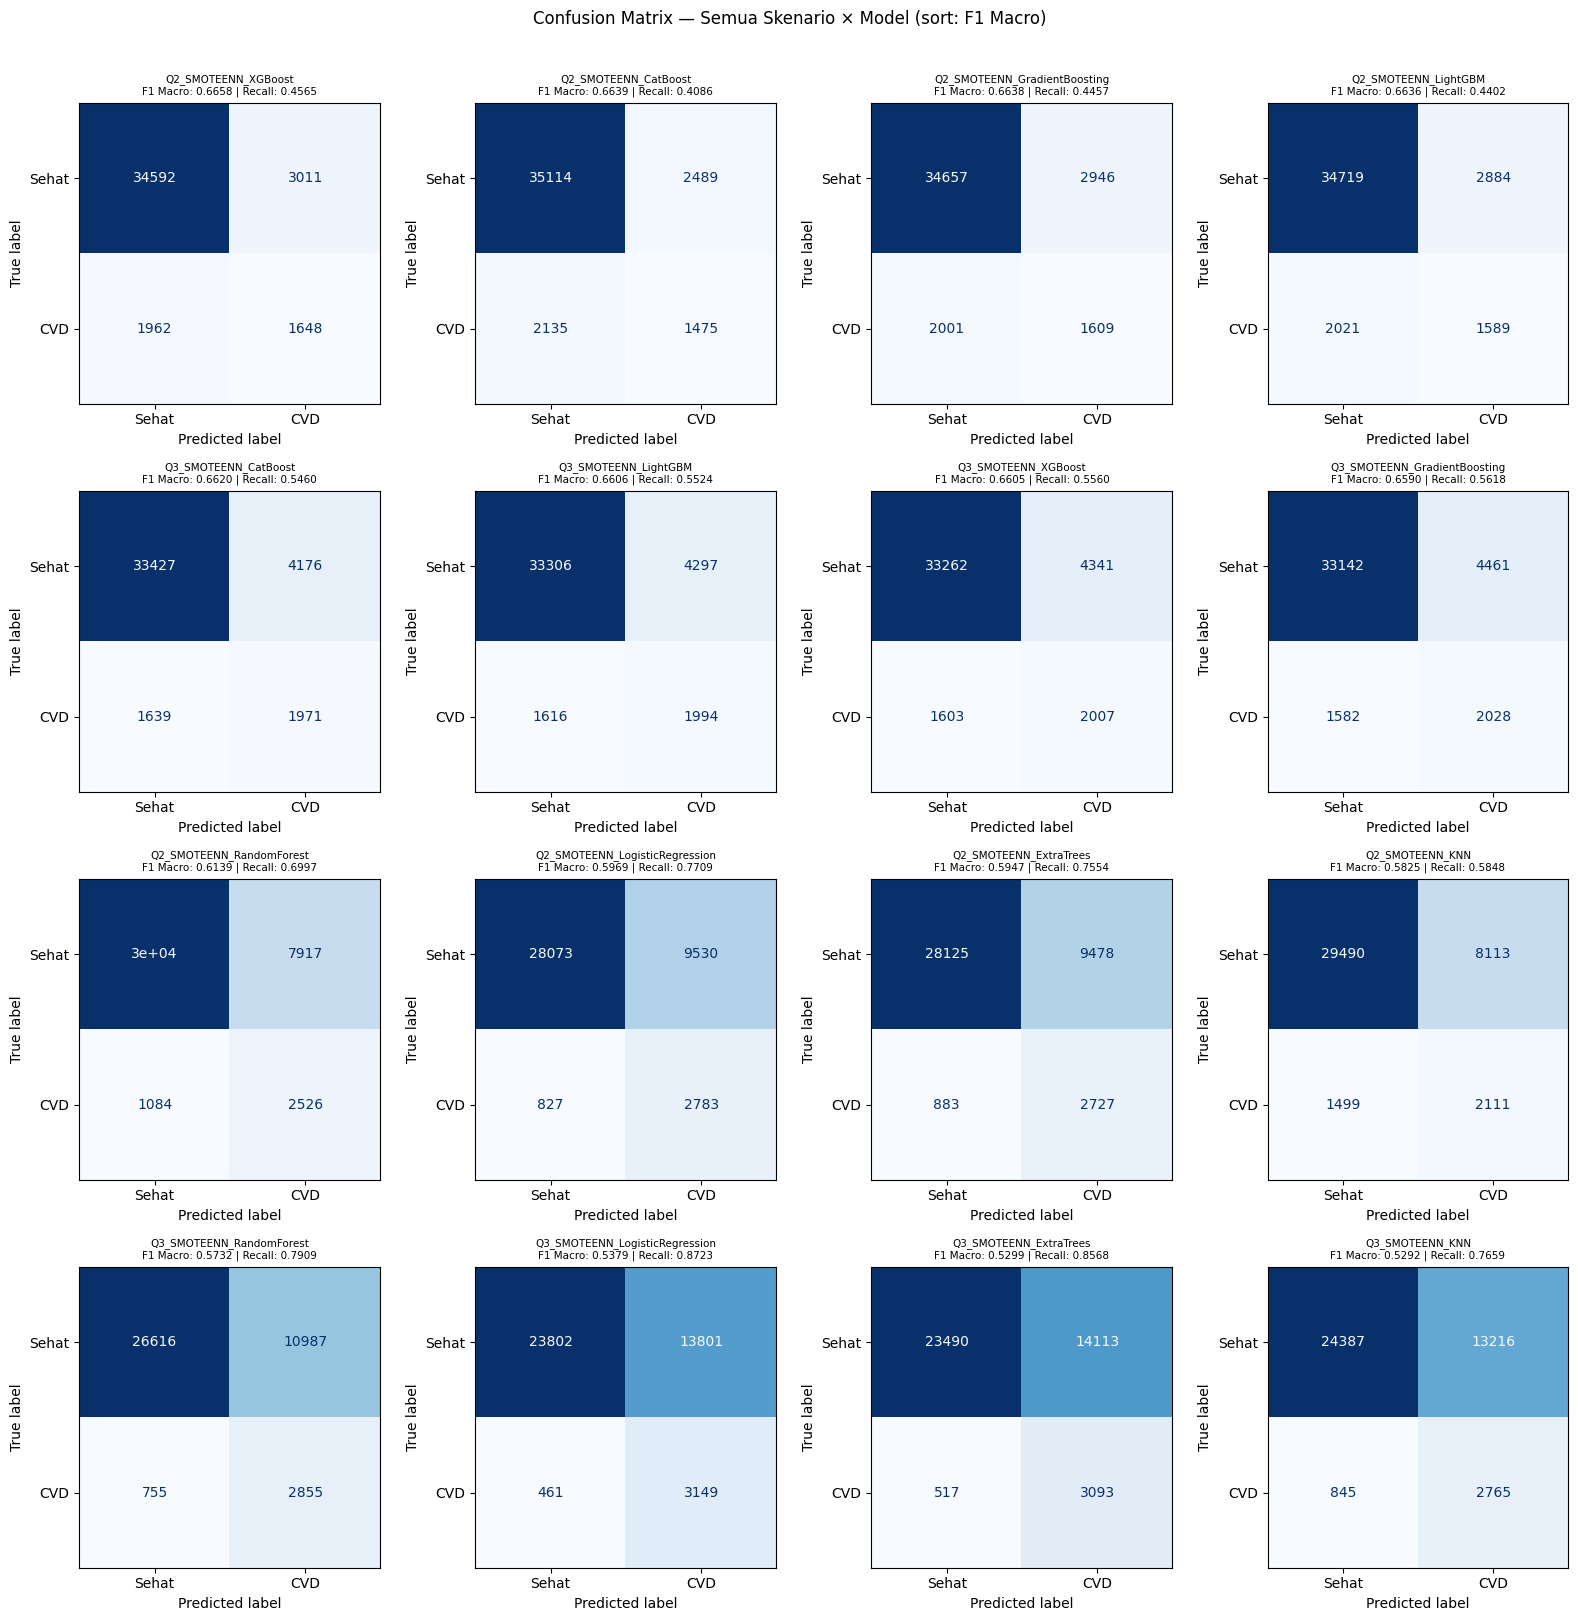

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Konfigurasi skenario (perbaiki duplikat key) ─────────────────────────────
scenarios = {
    'Q2_SMOTEENN': {
        'kuartil'   : 2,
        'resampler' : SMOTEENN(random_state=42),
    },
    'Q3_SMOTEENN': {                               # ← key diperbaiki (was duplikat)
        'kuartil'   : 3,
        'resampler' : SMOTEENN(random_state=42),
    },
}

# ── Definisi model ────────────────────────────────────────────────────────────
models = {
    'XGBoost'           : XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                         subsample=0.8, colsample_bytree=0.8,
                                         eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM'          : LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                          subsample=0.8, colsample_bytree=0.8,
                                          random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost'          : CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05,
                                              random_state=42, verbose=0),
    'RandomForest'      : RandomForestClassifier(n_estimators=300, max_depth=6,
                                                  random_state=42, n_jobs=-1),
    'ExtraTrees'        : ExtraTreesClassifier(n_estimators=300, max_depth=6,
                                                random_state=42, n_jobs=-1),
    'GradientBoosting'  : GradientBoostingClassifier(n_estimators=300, max_depth=6,
                                                      learning_rate=0.05, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'KNN'               : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

# ── Loop skenario × model ─────────────────────────────────────────────────────
results_all   = {}
conf_matrices = {}
N_total       = len(feat_imp_df)

for sc_name, sc_cfg in scenarios.items():
    N_FEATURES        = int(np.ceil(N_total * sc_cfg['kuartil'] / 4))  # /4 untuk kuartil
    selected_features = feat_imp_df['feature'].head(N_FEATURES).tolist()

    X_train_sc = X_train[selected_features]
    X_test_sc  = X_test[selected_features]

    if sc_cfg['resampler'] is None:
        X_res, y_res = X_train_sc, y_train
        spw = (y_train == 0).sum() / (y_train == 1).sum()
    else:
        X_res, y_res = sc_cfg['resampler'].fit_resample(X_train_sc, y_train)
        spw = 1.0

    print(f"\n{'='*60}")
    print(f"Skenario : {sc_name} | {N_FEATURES} fitur ({sc_cfg['kuartil']*25}% teratas)")
    print(f"{'='*60}")

    for model_name, clf in tqdm(models.items(), desc=sc_name):
        if hasattr(clf, 'scale_pos_weight'):
            clf.set_params(scale_pos_weight=spw)
        if hasattr(clf, 'class_weight'):
            clf.set_params(class_weight='balanced' if spw > 1 else None)

        clf.fit(X_res, y_res)

        y_pred = clf.predict(X_test_sc)
        y_prob = clf.predict_proba(X_test_sc)[:, 1]
        report = classification_report(y_test, y_pred, output_dict=True)
        cm     = confusion_matrix(y_test, y_pred)

        key = f"{sc_name}_{model_name}"
        results_all[key] = {
            'Skenario'      : sc_name,
            'Kuartil'       : f"Q{sc_cfg['kuartil']} ({sc_cfg['kuartil']*25}%)",
            'Model'         : model_name,
            'N Fitur'       : N_FEATURES,
            # Urutan metrik: F1 Macro → F1 Weighted → Recall → Precision → Accuracy → AUC
            'F1 Macro'      : report['macro avg']['f1-score'],
            'F1 Weighted'   : report['weighted avg']['f1-score'],
            'Recall CVD'    : report['1']['recall'],
            'Precision CVD' : report['1']['precision'],
            'F1 CVD'        : report['1']['f1-score'],
            'Accuracy'      : report['accuracy'],
            'AUC'           : roc_auc_score(y_test, y_prob),
            'TN'            : cm[0, 0],
            'FP'            : cm[0, 1],
            'FN'            : cm[1, 0],
            'TP'            : cm[1, 1],
        }
        conf_matrices[key] = cm

# ── Tabel hasil (sort by F1 Macro) ───────────────────────────────────────────
results_df = pd.DataFrame(results_all).T.round(4)
results_df[['N Fitur', 'TN', 'FP', 'FN', 'TP']] = \
    results_df[['N Fitur', 'TN', 'FP', 'FN', 'TP']].astype(int)

cols_show = ['Skenario', 'Kuartil', 'Model', 'N Fitur',
             'F1 Macro', 'F1 Weighted', 'Recall CVD',
             'Precision CVD', 'F1 CVD', 'Accuracy', 'AUC']

print("\n── Perbandingan Semua Skenario × Model (sort by F1 Macro) ──")
print(results_df[cols_show].sort_values('F1 Macro', ascending=False).to_string())

# ── Ringkasan per skenario ────────────────────────────────────────────────────
print("\n── Rata-rata Performa per Skenario ──")
summary = results_df.groupby('Skenario')[
    ['F1 Macro', 'F1 Weighted', 'Recall CVD', 'Precision CVD', 'Accuracy', 'AUC']
].mean().round(4).sort_values('F1 Macro', ascending=False)
print(summary.to_string())

# ── Kombinasi terbaik ─────────────────────────────────────────────────────────
best     = results_df.sort_values('F1 Macro', ascending=False).iloc[0]
best_key = results_df.sort_values('F1 Macro', ascending=False).index[0]

print(f"\n✅ Kombinasi terbaik (berdasarkan F1 Macro):")
print(f"   Skenario     : {best['Skenario']}")
print(f"   Kuartil      : {best['Kuartil']}")
print(f"   Model        : {best['Model']}")
print(f"   N Fitur      : {best['N Fitur']}")
print(f"   ─────────────────────────────")
print(f"   F1 Macro     : {best['F1 Macro']}")
print(f"   F1 Weighted  : {best['F1 Weighted']}")
print(f"   Recall CVD   : {best['Recall CVD']}")
print(f"   Precision CVD: {best['Precision CVD']}")
print(f"   F1 CVD       : {best['F1 CVD']}")
print(f"   Accuracy     : {best['Accuracy']}")
print(f"   AUC          : {best['AUC']}")
print(f"\n   Confusion Matrix ({best_key}):")
print(f"   {'':15} Pred Sehat   Pred CVD")
print(f"   {'Actual Sehat':15} {int(best['TN']):>10}   {int(best['FP']):>8}")
print(f"   {'Actual CVD':15} {int(best['FN']):>10}   {int(best['TP']):>8}")

# ── Confusion Matrix grid ─────────────────────────────────────────────────────
sorted_keys = results_df.sort_values('F1 Macro', ascending=False).index.tolist()
n_total     = len(sorted_keys)
ncols       = 4
nrows       = int(np.ceil(n_total / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
axes = axes.flatten()

for i, key in enumerate(sorted_keys):
    cm   = conf_matrices[key]
    row  = results_all[key]
    disp = ConfusionMatrixDisplay(cm, display_labels=['Sehat', 'CVD'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(
        f"{key}\n"
        f"F1 Macro: {row['F1 Macro']:.4f} | Recall: {row['Recall CVD']:.4f}",
        fontsize=7.5
    )

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrix — Semua Skenario × Model (sort: F1 Macro)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()